経験バッファへ正解データとなるデータを収集するSACはうまく学習できていて推論できている。<br>一方で、CQL-SACはその経験バッファを使ってのオフライン学習なのにうまく推論できていない。CQLペナルティの重みのハイパーパラメータをかなり小さくして、CQLの要素を小さくしてSACの要素を大きくしても推論結果はあまり変わらずだった。<br>経験バッファの正解データの行動が0で偏っているため、0以外の行動のCQLペナルティが過剰に効いているのかもしれない。時々1の行動が出るのは行動の連続値を四捨五入で整数値にしているので0.5以上の連続値になった時の行動と思われる。<br>では、CQLペナルティの重みを0にして実質SACの形として、オフライン学習のSACならばどうか？<br>試していないけれど、それは微妙。理由として、オンライン学習SACがうまくいくのは、actorが筋のイイ行動を出すと環境からイイ状態と報酬が返ってきて、それが経験バッファに入り、そしてcriticもTD誤差を算出する際にイイ行動と状態と報酬を使えるのでTD誤差も有意に小さくできて、criticは学習が行われ、そしてactorも学習される。<br>一方で、オフラインSACだと筋の微妙な行動や経験や報酬のデータがいつまでも経験バッファにあり、criticはいつまでもそのデータを学習で使う事になるので、TD誤差がなかなか有意に小さくできず、その結果criticの学習はいつまでも微妙で、そしてactorの学習もいつまでも微妙になる。また、経験バッファに無い行動をactorが推論した場合、criticはその行動に対する価値を出力しようにもドメイン範囲外の入力になるので、出力する価値は適当になってしまい、環境からの報酬での是正も無いので、これもcriticの学習が微妙になり、actorの学習も微妙になる形になる。<br>よって、CQL-SACは正解データである経験バッファの行動に偏りがあると微妙な結果になる。<br>一方で、正解データである経験バッファの行動がある程度散らばっている場合は、大当たりはしないけれど大外しもしないような行動を取るような形で使える、と考察される。

In [ ]:
!pip install stable-baselines3==2.7.1
!pip install d3rlpy==2.8.1
!pip install gymnasium==1.2.3  # コンパチの都合でgymnasiumのバージョンを保つためにこの順番でインストールする

In [ ]:
import collections
import random

import d3rlpy
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import stable_baselines3 as sb3
import torch


print("d3rlpy:", d3rlpy.__version__)
print("gymnasium:", gym.__version__)
print("matplotlib:", matplotlib.__version__)
print("numpy:", np.__version__)
print("stable baselines3:", sb3.__version__)
print("pytorch:", torch.__version__)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


d3rlpy: 2.8.1
gymnasium: 1.2.3
matplotlib: 3.10.0
numpy: 2.0.2
stable baselines3: 2.7.1
pytorch: 2.10.0+cu128


In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    DEVICE_STRING = "cuda:0"
else:
    DEVICE_STRING = "cpu"

In [ ]:
class MyInventoryEnv(gym.Env):
    def __init__(self, continuous_action_flag, initial_inventory, max_step, lead_time):
        super().__init__()
        # ステップ数をカウントするため
        self.current_step = 0
        # 行動が連続的かどうか(違う場合は離散的)のフラグ
        self.continuous_action_flag = continuous_action_flag
        # 1エピソードの最大ステップ数
        self.max_step = max_step
        # 発注から納品までのリードタイム
        self.lead_time = lead_time
        # 納品待ち数を保存するキュー # 初期値は[0, 0]とする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time,
                                                maxlen=self.lead_time)
        # 行動(変数名はself.action_spaceがお作法)を定義
        if self.continuous_action_flag:  # 行動は連続値
            self.action_space = gym.spaces.Box(low=0,  # 発注量0～10を行動として、array形状を(1, )とする
                                               high=10,
                                               shape=(1, ),
                                               dtype=np.float32)
        else:  # 行動は離散値
            self.action_space = gym.spaces.Discrete(n=11,  # 発注量は0から11個の離散値で0～10の行動となる # array形状は( )でint扱いになる
                                                    seed=42,
                                                    start=0,
                                                    dtype=np.int32)
        # 状態(変数名はself.observation_spaceがお作法)を定義
        self.observation_space = gym.spaces.Box(low=0,  # 在庫数と納品待ち数(翌日と翌々日)として0～50の値で、array形状を(3, )とする
                                                high=50,
                                                shape=(1+self.lead_time, ),
                                                dtype=np.float32)
        # 状態の初期値を定義して、状態を定義する
        self.initial_state = np.array([initial_inventory]+list(self.delivery_queue),
                                      dtype=np.float32)
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # 状態を初期状態にする
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため
        # キューを初期値にする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time, maxlen=self.lead_time)
        # お作法としてinfo用の変数を作成する
        info = {}
        # ステップ数もリセットする
        self.current_step = 0
        # 初期状態とinfoを戻す
        return self.state, info

    def step(self, action):  # gymのお作法としてstep関数の引数はactionのみとする
        # ステップ数を+1する
        self.current_step = self.current_step + 1
        # 行動が連続値の時は整数部分を取得、離散値の時はそのまま
        if self.continuous_action_flag:
            preprocessed_action = np.round(a=action[0],  # 形状は(1, )なので[0]で要素を取得して四捨五入する
                                           decimals=0)
        else:
            preprocessed_action = int(action)  # そのまま(念のためint型にする)
        # 前々日に発注した数を納品する(キューの前から1つ取り出す)
        arrived_item = self.delivery_queue.popleft()
        # 需要は期待値が3のポアソン分布からサンプリングする
        demand = np.random.poisson(lam=3,
                                   size=(1, ))
        # サンプリングした需要と、納品数を踏まえて、在庫量を更新する
        inventory = np.clip(a=self.state[0] - demand[0] + arrived_item,
                            a_min=0,  # 在庫量はマイナスにはならない
                            a_max=50,  # 在庫量はself.observation_stateで定義したhigh=50を超えないようにするため
                            dtype=np.float32)
        # 行動(発注量)をキューの後ろに保存する
        self.delivery_queue.append(preprocessed_action)
        # 状態(在庫量と納品待ち数)を更新する
        self.state = np.array([inventory]+list(self.delivery_queue),
                              dtype=np.float32)
        # 在庫数15を基準として報酬を設定する # 在庫数15付近を保つように行動するようになると思う
        delta = abs(self.state[0] - 15)
        if 0 < delta < 5:
            reward = 1.0
        elif 5 <= delta < 10:
            reward = 0
        else:
            reward = - (delta * 0.1)
        # 発注を行う場合は発注コスト発生として報酬を減らす # ポアソン分布の期待値3の需要を見破られて発注を定期的に3にする事を防ぐ
        if preprocessed_action != 0:
            reward = reward - 0.5
        # 在庫量が0になった場合は在庫管理が適切でなかったとしてterminatedをtrueにする
        if self.state[0] == 0:
            terminated = True
        else:
            terminated = False
        # ステップ数が最大ステップ数になったらtruncatedをtrueにする
        if self.current_step == self.max_step:
            truncated = True
        else:
            truncated = False
        # お作法としてinfoを用意する
        info = {}
        # 状態、報酬、terminated、truncated、infoの並びで戻す
        return self.state, reward, terminated, truncated, info

In [ ]:
def collect_data_by_trained_actor(algorithm_name, env, model, timestep, deterministic_predict_flag, random_sampling_flag, random_sampling_ratio):
    state_list = []
    action_list = []
    reward_list = []
    terminated_list = []
    truncated_list = []
    state, _ = env.reset()
    for i in range(timestep):
        predicted_action, hidden = model.predict(observation=state,
                                                 deterministic=deterministic_predict_flag)
        if random_sampling_flag:  # ランダムサンプリングのフラグがTrueの場合は、
            if random.uniform(a=0, b=1.0) < random_sampling_ratio:  # 指定の確率で、
                predicted_action = env.action_space.sample()  # 行動をランダムサンプリングで上書きする
        next_state, reward, terminated, truncated, info = env.step(action=predicted_action)
        state_list.append(state)
        action_list.append(predicted_action)
        reward_list.append(reward)
        terminated_list.append(terminated)
        truncated_list.append(truncated)
        if terminated or truncated:
            state, _ = env.reset()
        else:
            state = next_state
    state_array = np.array(object=state_list,
                           dtype=np.float32)  # 形状は(timestep数, 3)
    action_array = np.array(object=action_list,
                            dtype=np.float32).reshape((-1, 1))  # 形状は(timestep数, 1)
    reward_array = np.array(object=reward_list,
                            dtype=np.float32)  # 形状は(timestep数, )
    terminated_array = np.array(object=terminated_list,
                                dtype=np.float32)  # 形状は(timestep数, )
    truncated_array = np.array(object=truncated_list,
                               dtype=np.float32)  # 形状は(timestep数, )
    return (state_array, action_array, reward_array, terminated_array, truncated_array)

In [ ]:
def inference_timestep(algorithm_name, env, model, timestep):
    state, _ = env.reset()
    total_reward = 0
    inventory_list = []
    available_inventory_list = []
    for i in range(timestep):
        print("{a}:{b}ステップ: 在庫量:{c} 翌納品:{d} 翌々納品(action):{e}".format(a=algorithm_name, b=i, c=state[0], d=state[1], e=state[2]))
        inventory_list.append(state[0])
        available_inventory_list.append(state[0]+state[1]+state[2])
        if algorithm_name in ["CQL-SAC", "CQL-DDQN"]:
            state = state.reshape(1, -1)  # d3rlpyライブラリーのモデルは入力データにバッチ軸を求めるので、形状を(3, )から(1, 3)に変える
            # https://d3rlpy.readthedocs.io/en/latest/references/algos.html#d3rlpy.algos.QLearningAlgoBase.predict
            predicted_action = model.predict(x=state)  # 出力の形状は(1, 1) # (入力したstateの時系列数, actionの次元数)
            predicted_action = predicted_action[0]  # [0]で取得して(1, )にする # env.stepでは行動の形状は(1, )を想定しているため
        else:
            predicted_action, hidden = model.predict(observation=state,
                                                     deterministic=True)
        next_state, reward, terminated, truncated, info = env.step(action=predicted_action)
        total_reward = total_reward + reward
        if terminated or truncated:
            break
        state = next_state
    print("{a}:報酬合計:{b}".format(a=algorithm_name, b=total_reward))
    return inventory_list, available_inventory_list

In [ ]:
# 経験バッファにはSACで推論した行動のデータを保存するために、まずは環境からのデータを使ってSACを学習する
env_sac = MyInventoryEnv(continuous_action_flag=True,  # SACは連続的な行動を対象とする
                         initial_inventory=20,
                         max_step=31,
                         lead_time=2)
# https://stable-baselines3.readthedocs.io/en/master/modules/sac.html#stable_baselines3.sac.SAC
model_sac = sb3.SAC(policy="MlpPolicy",
                    env=env_sac,
                    learning_rate=0.0003,
                    buffer_size=2048,  # 経験バッファに保存するステップ数
                    learning_starts=64,  # 学習を開始する経験バッファ保存ステップ数
                    batch_size=64,
                    tau=0.005,  # ターゲットcriticのパラメータ更新を、criticのパラメータで行う割合
                    gamma=0.98,  # critic学習で正解データとなるターゲットQを算出する際の割引率
                    train_freq=1,  # 経験バッファにlearning_startsステップ数保存されて以降、何ステップ毎にactorとcriticの学習を行うか
                    ent_coef="auto",  # actor学習での損失値の算出や、critic学習でのターゲットQの算出にて、actorの推論による方策のエントロピー(ランダム性の尺度:−logπ(a∣s))を盛り込む割合(autoだと学習して動的な値になる)
                    target_update_interval=1,  # criticのパラメータ更新に伴って、ターゲットcriticを更新する間隔(1ならばcriticを学習するとターゲットcriticも学習する)
                    # verbose=1,
                    device=DEVICE)
model_sac.learn(total_timesteps=102400,
                progress_bar=True)

In [ ]:
datas_array = collect_data_by_trained_actor(algorithm_name="sac",  # 学習したSACによる推論の行動で経験バッファ用のデータを環境から収集する # 行動は連続的
                                            env=env_sac,
                                            model=model_sac,
                                            timestep=5000,  # 5000件のデータを収集する
                                            deterministic_predict_flag=False,  # Trueは決定的(最も高い確率になるμの行動)、Falseは確率的(μとσでの正規分布からのランダムサンプリング)
                                            random_sampling_flag=True,  # 一部の行動をランダムサンプリングにするかどうか
                                            random_sampling_ratio=0.1)  # ランダムサンプリングにする確率
dataset_cql_sac = d3rlpy.dataset.MDPDataset(observations=datas_array[0],
                                            actions=datas_array[1],
                                            rewards=datas_array[2],
                                            terminals=datas_array[3],
                                            timeouts=datas_array[4])

In [ ]:
# https://d3rlpy.readthedocs.io/en/latest/references/algos.html#d3rlpy.algos.CQLConfig
# actorの損失値は「actor推論の行動の価値 + 重み * エントロピー」の逆符号
# criticの損失値は「SAC損失値 + CQL損失値」
# SAC損失値は「ターゲットQ - Q」 ※ターゲットQは経験バッファの次の状態からactorで推論した行動を用いる ※Qは経験バッファの行動を用いる
# CQL損失値は「重み * (ランダムな行動の価値 + actor推論の行動の価値 - 経験バッファの行動の価値)」
model_config_cql_sac = d3rlpy.algos.CQLConfig(batch_size=256,
                                              gamma=0.99,  # SAC損失値を求める際のターゲットQを算出する時の割引率
                                              actor_learning_rate=0.0001,  # actorの学習率
                                              critic_learning_rate=0.0003,  # criticの学習率
                                              temp_learning_rate=0.0001,  # SAC損失値を求める際のターゲットQを算出する時のエントロピー重みを動的に得る際の学習率
                                              alpha_learning_rate=0.0001,  # CQL損失値を求める際の動的重みを得る際の学習率
                                              tau=0.005,  # ターゲットcriticを更新する際のcriticパラメータを盛り込む割合
                                              initial_temperature=1.0,  # SAC損失値を求める際のターゲットQを算出する時のエントロピー重みの初期値
                                              initial_alpha=0.001,  # CQL損失値を求める際の動的重みの初期値
                                              n_critics=2,  # criticとターゲットcriticのペアの数(2ならばcriticが2つのターゲットcriticが2つの合計4つ)
                                              conservative_weight=0.01,  # CQL損失値を求める際の固定重み
                                              n_action_samples=30)  # CQL損失値を求める際の「ランダムな行動の価値」「actor推論の行動の価値」「経験バッファの行動の価値」を何個のデータから算出するか
model_cql_sac = model_config_cql_sac.create(device=DEVICE_STRING)

In [ ]:
# https://d3rlpy.readthedocs.io/en/latest/references/algos.html#d3rlpy.algos.QLearningAlgoBase.fit
model_cql_sac.fit(dataset=dataset_cql_sac,
                  n_steps=20000,
                  n_steps_per_epoch=1000,
                  with_timestamp=True,
                  show_progress=True)

2026-04-05 05:11.00 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(3,)]), action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.CONTINUOUS: 1>, action_size=1)
2026-04-05 05:11.00 [debug    ] Building models...            
2026-04-05 05:11.00 [debug    ] Models have been built.       
2026-04-05 05:11.00 [info     ] Directory is created at d3rlpy_logs/CQL_20260405051100
2026-04-05 05:11.00 [info     ] Parameters                     params={'observation_shape': [3], 'action_size': 1, 'config': {'type': 'cql', 'params': {'batch_size': 256, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': False, 'actor_learning_rate': 0.0001, 'critic_learning_rate': 0.0003, 'temp_le

Epoch 1/20:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-05 05:11.26 [info     ] CQL_20260405051100: epoch=1 step=1000 epoch=1 metrics={'time_sample_batch': 0.0032768399715423584, 'time_algorithm_update': 0.022344300985336303, 'critic_loss': 0.5333851166665554, 'conservative_loss': -9.230041599221295e-05, 'alpha': 0.0009523384495987556, 'actor_loss': -0.7296071877828799, 'temp': 0.9516478419899941, 'temp_loss': 1.5860201526880264, 'time_step': 0.025719518184661866} step=1000
2026-04-05 05:11.26 [info     ] Model parameters are saved to d3rlpy_logs/CQL_20260405051100/model_1000.d3


Epoch 2/20:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-05 05:11.52 [info     ] CQL_20260405051100: epoch=2 step=2000 epoch=2 metrics={'time_sample_batch': 0.0032726709842681883, 'time_algorithm_update': 0.022040485620498658, 'critic_loss': 0.5271577570736409, 'conservative_loss': -8.143635181477294e-05, 'alpha': 0.0008658673606114462, 'actor_loss': -2.4459450162649157, 'temp': 0.8641405947208405, 'temp_loss': 1.4437279161214829, 'time_step': 0.025415257930755615} step=2000
2026-04-05 05:11.52 [info     ] Model parameters are saved to d3rlpy_logs/CQL_20260405051100/model_2000.d3


...

Epoch 19/20:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-05 05:19.17 [info     ] CQL_20260405051100: epoch=19 step=19000 epoch=19 metrics={'time_sample_batch': 0.0033391366004943846, 'time_algorithm_update': 0.022407941818237305, 'critic_loss': 0.5688838223814965, 'conservative_loss': -1.9279797990748194e-05, 'alpha': 0.00018298003452946432, 'actor_loss': -19.336100242614744, 'temp': 0.19126294673979283, 'temp_loss': 0.21046058848500251, 'time_step': 0.025845451354980467} step=19000
2026-04-05 05:19.17 [info     ] Model parameters are saved to d3rlpy_logs/CQL_20260405051100/model_19000.d3


Epoch 20/20:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-05 05:19.43 [info     ] CQL_20260405051100: epoch=20 step=20000 epoch=20 metrics={'time_sample_batch': 0.0033231770992279055, 'time_algorithm_update': 0.02237881350517273, 'critic_loss': 0.5658090623617172, 'conservative_loss': -1.7616664721572306e-05, 'alpha': 0.0001671200296113966, 'actor_loss': -19.357781034469603, 'temp': 0.17550627079606057, 'temp_loss': 0.18446327251195907, 'time_step': 0.025796729326248168} step=20000
2026-04-05 05:19.43 [info     ] Model parameters are saved to d3rlpy_logs/CQL_20260405051100/model_20000.d3


[(1,
  {'time_sample_batch': 0.0032768399715423584,
   'time_algorithm_update': 0.022344300985336303,
   'critic_loss': 0.5333851166665554,
   'conservative_loss': -9.230041599221295e-05,
   'alpha': 0.0009523384495987556,
   'actor_loss': -0.7296071877828799,
   'temp': 0.9516478419899941,
   'temp_loss': 1.5860201526880264,
   'time_step': 0.025719518184661866}),
 (2,
  {'time_sample_batch': 0.0032726709842681883,
   'time_algorithm_update': 0.022040485620498658,
   'critic_loss': 0.5271577570736409,
   'conservative_loss': -8.143635181477294e-05,
   'alpha': 0.0008658673606114462,
   'actor_loss': -2.4459450162649157,
   'temp': 0.8641405947208405,
   'temp_loss': 1.4437279161214829,
   'time_step': 0.025415257930755615}),
 (3,
  {'time_sample_batch': 0.0032767617702484132,
   'time_algorithm_update': 0.022208248138427734,
   'critic_loss': 0.714774390488863,
   'conservative_loss': -6.886045812279918e-05,
   'alpha': 0.0007911409232765436,
   'actor_loss': -5.327632603883743,
   't

CQL-SAC:0ステップ: 在庫量:20.0 翌納品:0.0 翌々納品(action):0.0
CQL-SAC:1ステップ: 在庫量:16.0 翌納品:0.0 翌々納品(action):0.0
CQL-SAC:2ステップ: 在庫量:15.0 翌納品:0.0 翌々納品(action):-0.0
CQL-SAC:3ステップ: 在庫量:13.0 翌納品:-0.0 翌々納品(action):-0.0
CQL-SAC:4ステップ: 在庫量:8.0 翌納品:-0.0 翌々納品(action):-0.0
CQL-SAC:5ステップ: 在庫量:6.0 翌納品:-0.0 翌々納品(action):-1.0
CQL-SAC:6ステップ: 在庫量:2.0 翌納品:-1.0 翌々納品(action):-0.0
CQL-SAC:報酬合計:-1.8000000715255737
SAC:0ステップ: 在庫量:20.0 翌納品:0.0 翌々納品(action):0.0
SAC:1ステップ: 在庫量:17.0 翌納品:0.0 翌々納品(action):6.0
SAC:2ステップ: 在庫量:14.0 翌納品:6.0 翌々納品(action):0.0
SAC:3ステップ: 在庫量:16.0 翌納品:0.0 翌々納品(action):6.0
SAC:4ステップ: 在庫量:11.0 翌納品:6.0 翌々納品(action):0.0
SAC:5ステップ: 在庫量:14.0 翌納品:0.0 翌々納品(action):9.0
SAC:6ステップ: 在庫量:13.0 翌納品:9.0 翌々納品(action):0.0
SAC:7ステップ: 在庫量:18.0 翌納品:0.0 翌々納品(action):0.0
SAC:8ステップ: 在庫量:16.0 翌納品:0.0 翌々納品(action):8.0
SAC:9ステップ: 在庫量:13.0 翌納品:8.0 翌々納品(action):0.0
SAC:10ステップ: 在庫量:17.0 翌納品:0.0 翌々納品(action):0.0
SAC:11ステップ: 在庫量:16.0 翌納品:0.0 翌々納品(action):8.0
SAC:12ステップ: 在庫量:12.0 翌納品:8.0 翌々納品(action):0.0
SAC:13ステップ: 在庫量:19.0 翌納品:0.0 翌

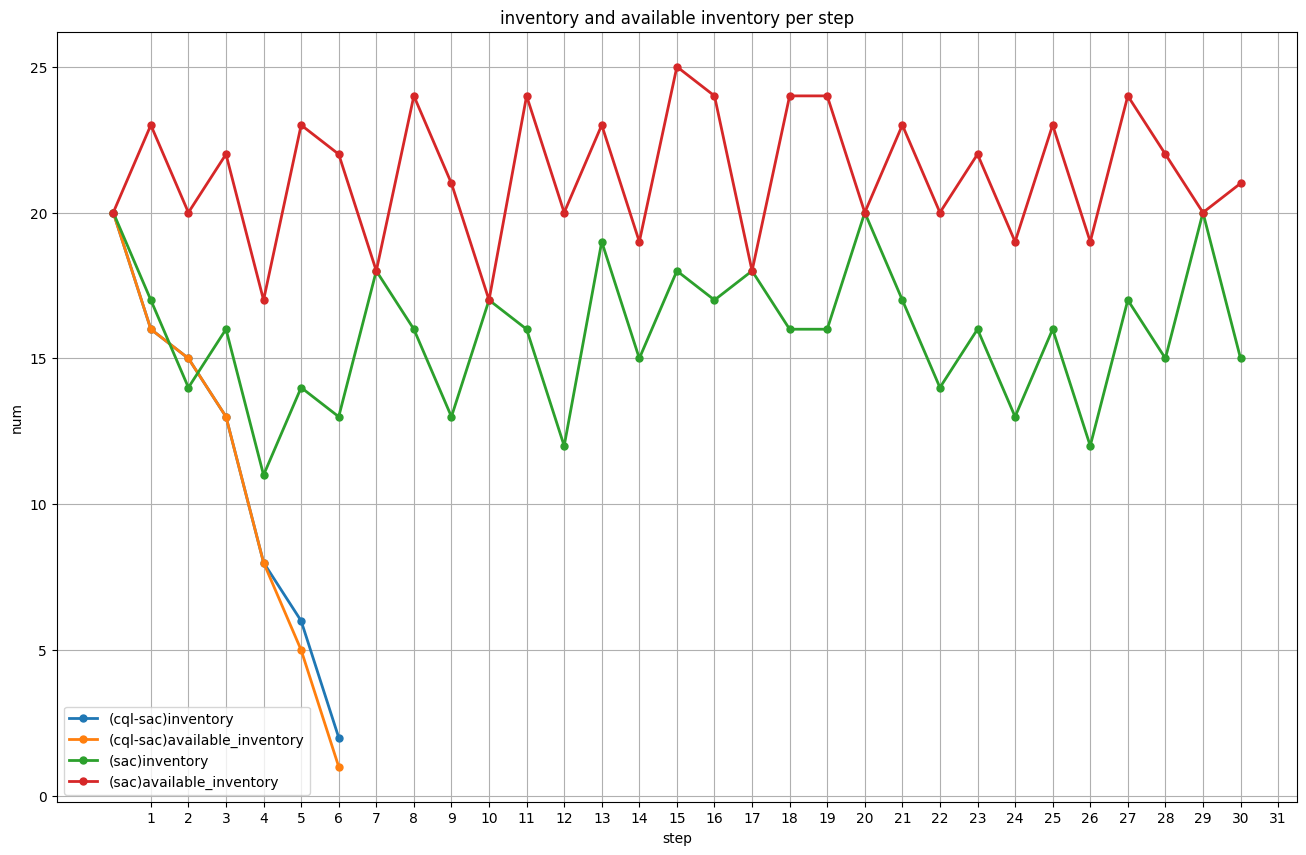

In [ ]:
env_cql_sac = MyInventoryEnv(continuous_action_flag=True,
                             initial_inventory=20,
                             max_step=31,
                             lead_time=2)
inventory_list_cql_sac, available_inventory_list_cql_sac = inference_timestep(algorithm_name="CQL-SAC",
                                                                              env=env_cql_sac,
                                                                              model=model_cql_sac,
                                                                              timestep=31)
inventory_list_sac, available_inventory_list_sac = inference_timestep(algorithm_name="SAC",
                                                                      env=env_sac,
                                                                      model=model_sac,
                                                                      timestep=31)
fig, (ax1) = plt.subplots(nrows=1, ncols=1, figsize=(16, 10))
ax1.plot(np.arange(stop=len(inventory_list_cql_sac)),
         inventory_list_cql_sac,
         label="(cql-sac)inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(available_inventory_list_cql_sac)),
         available_inventory_list_cql_sac,
         label="(cql-sac)available_inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(inventory_list_sac)),
         inventory_list_sac,
         label="(sac)inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(available_inventory_list_sac)),
         available_inventory_list_sac,
         label="(sac)available_inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.legend(loc=0)
ax1.set_title(label="inventory and available inventory per step")
ax1.set_xlabel(xlabel="step")
ax1.set_ylabel(ylabel="num")
ax1.set_xticks(ticks=np.arange(stop=len(inventory_list_sac))+1)
ax1.grid(True)
plt.show()